## [1]

In [35]:
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

centers = [
    [+1,+1,+1,+1,+1,+1,+1,+1],  # Класс 0
    [-1,-1,-1,-1,-1,-1,-1,-1],  # Класс 1
    [+1,-1,+1,-1,+1,-1,+1,-1]   # Класс 2
]
    
X, y = make_blobs(n_samples=300, n_features=8, centers=centers, cluster_std=1.0, random_state=42)
df = pd.DataFrame(X, columns=[f'f{i}' for i in range(8)])
df['class'] = y

df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,class
0,0.672572,-0.580981,-1.705012,-1.055769,-0.441673,-0.923995,-0.461244,-1.920674,1
1,-1.021367,-1.747212,-3.424240,-0.115955,-0.263156,-1.281328,-0.933009,-0.484061,1
2,1.168461,0.317598,-0.006543,0.139879,2.317115,-1.118069,-1.121855,-1.607822,2
3,-0.000331,-1.677745,1.513908,-0.820418,1.350630,-0.510813,1.634721,0.109700,2
4,2.167782,1.254421,1.337603,0.588123,0.512394,0.567442,1.394452,0.579016,0


In [36]:
df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,class
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.325517,-0.187063,0.343180,-0.252184,0.355201,-0.334115,0.351192,-0.349594,1.000000
std,1.292712,1.371013,1.378682,1.374227,1.229573,1.289342,1.319359,1.381390,0.817861
min,-3.499406,-3.423879,-3.553921,-3.940389,-2.993736,-3.896255,-2.836205,-3.921350,0.000000
25%,-0.623097,-1.192265,-0.681774,-1.263831,-0.453808,-1.237777,-0.693786,-1.347217,0.000000
50%,0.524970,-0.243292,0.448813,-0.390059,0.432085,-0.502883,0.459961,-0.487668,1.000000
75%,1.259763,0.678107,1.439812,0.696012,1.214110,0.524419,1.282243,0.636665,2.000000
max,3.412615,4.852731,3.560085,3.720169,3.314659,3.190456,4.078881,3.270693,2.000000


In [37]:
# %% Корреляции
df.corr()

,f0,f1,f2,f3,f4,f5,f6,f7,class
f0,1.000000,0.292731,0.466759,0.190384,0.436194,0.155997,0.411425,0.210190,0.013685
f1,0.292731,1.000000,0.317656,0.483829,0.340222,0.393580,0.272962,0.537801,-0.556144
f2,0.466759,0.317656,1.000000,0.249065,0.484420,0.182332,0.420124,0.284792,-0.062048
f3,0.190384,0.483829,0.249065,1.000000,0.134912,0.438768,0.199117,0.457769,-0.615241
f4,0.436194,0.340222,0.484420,0.134912,1.000000,0.128660,0.363396,0.263195,-0.004841
f5,0.155997,0.393580,0.182332,0.438768,0.128660,1.000000,0.132814,0.432036,-0.587242
f6,0.411425,0.272962,0.420124,0.199117,0.363396,0.132814,1.000000,0.253800,0.026829
f7,0.210190,0.537801,0.284792,0.457769,0.263195,0.432036,0.253800,1.000000,-0.574121
class,0.013685,-0.556144,-0.062048,-0.615241,-0.004841,-0.587242,0.026829,-0.574121,1.000000


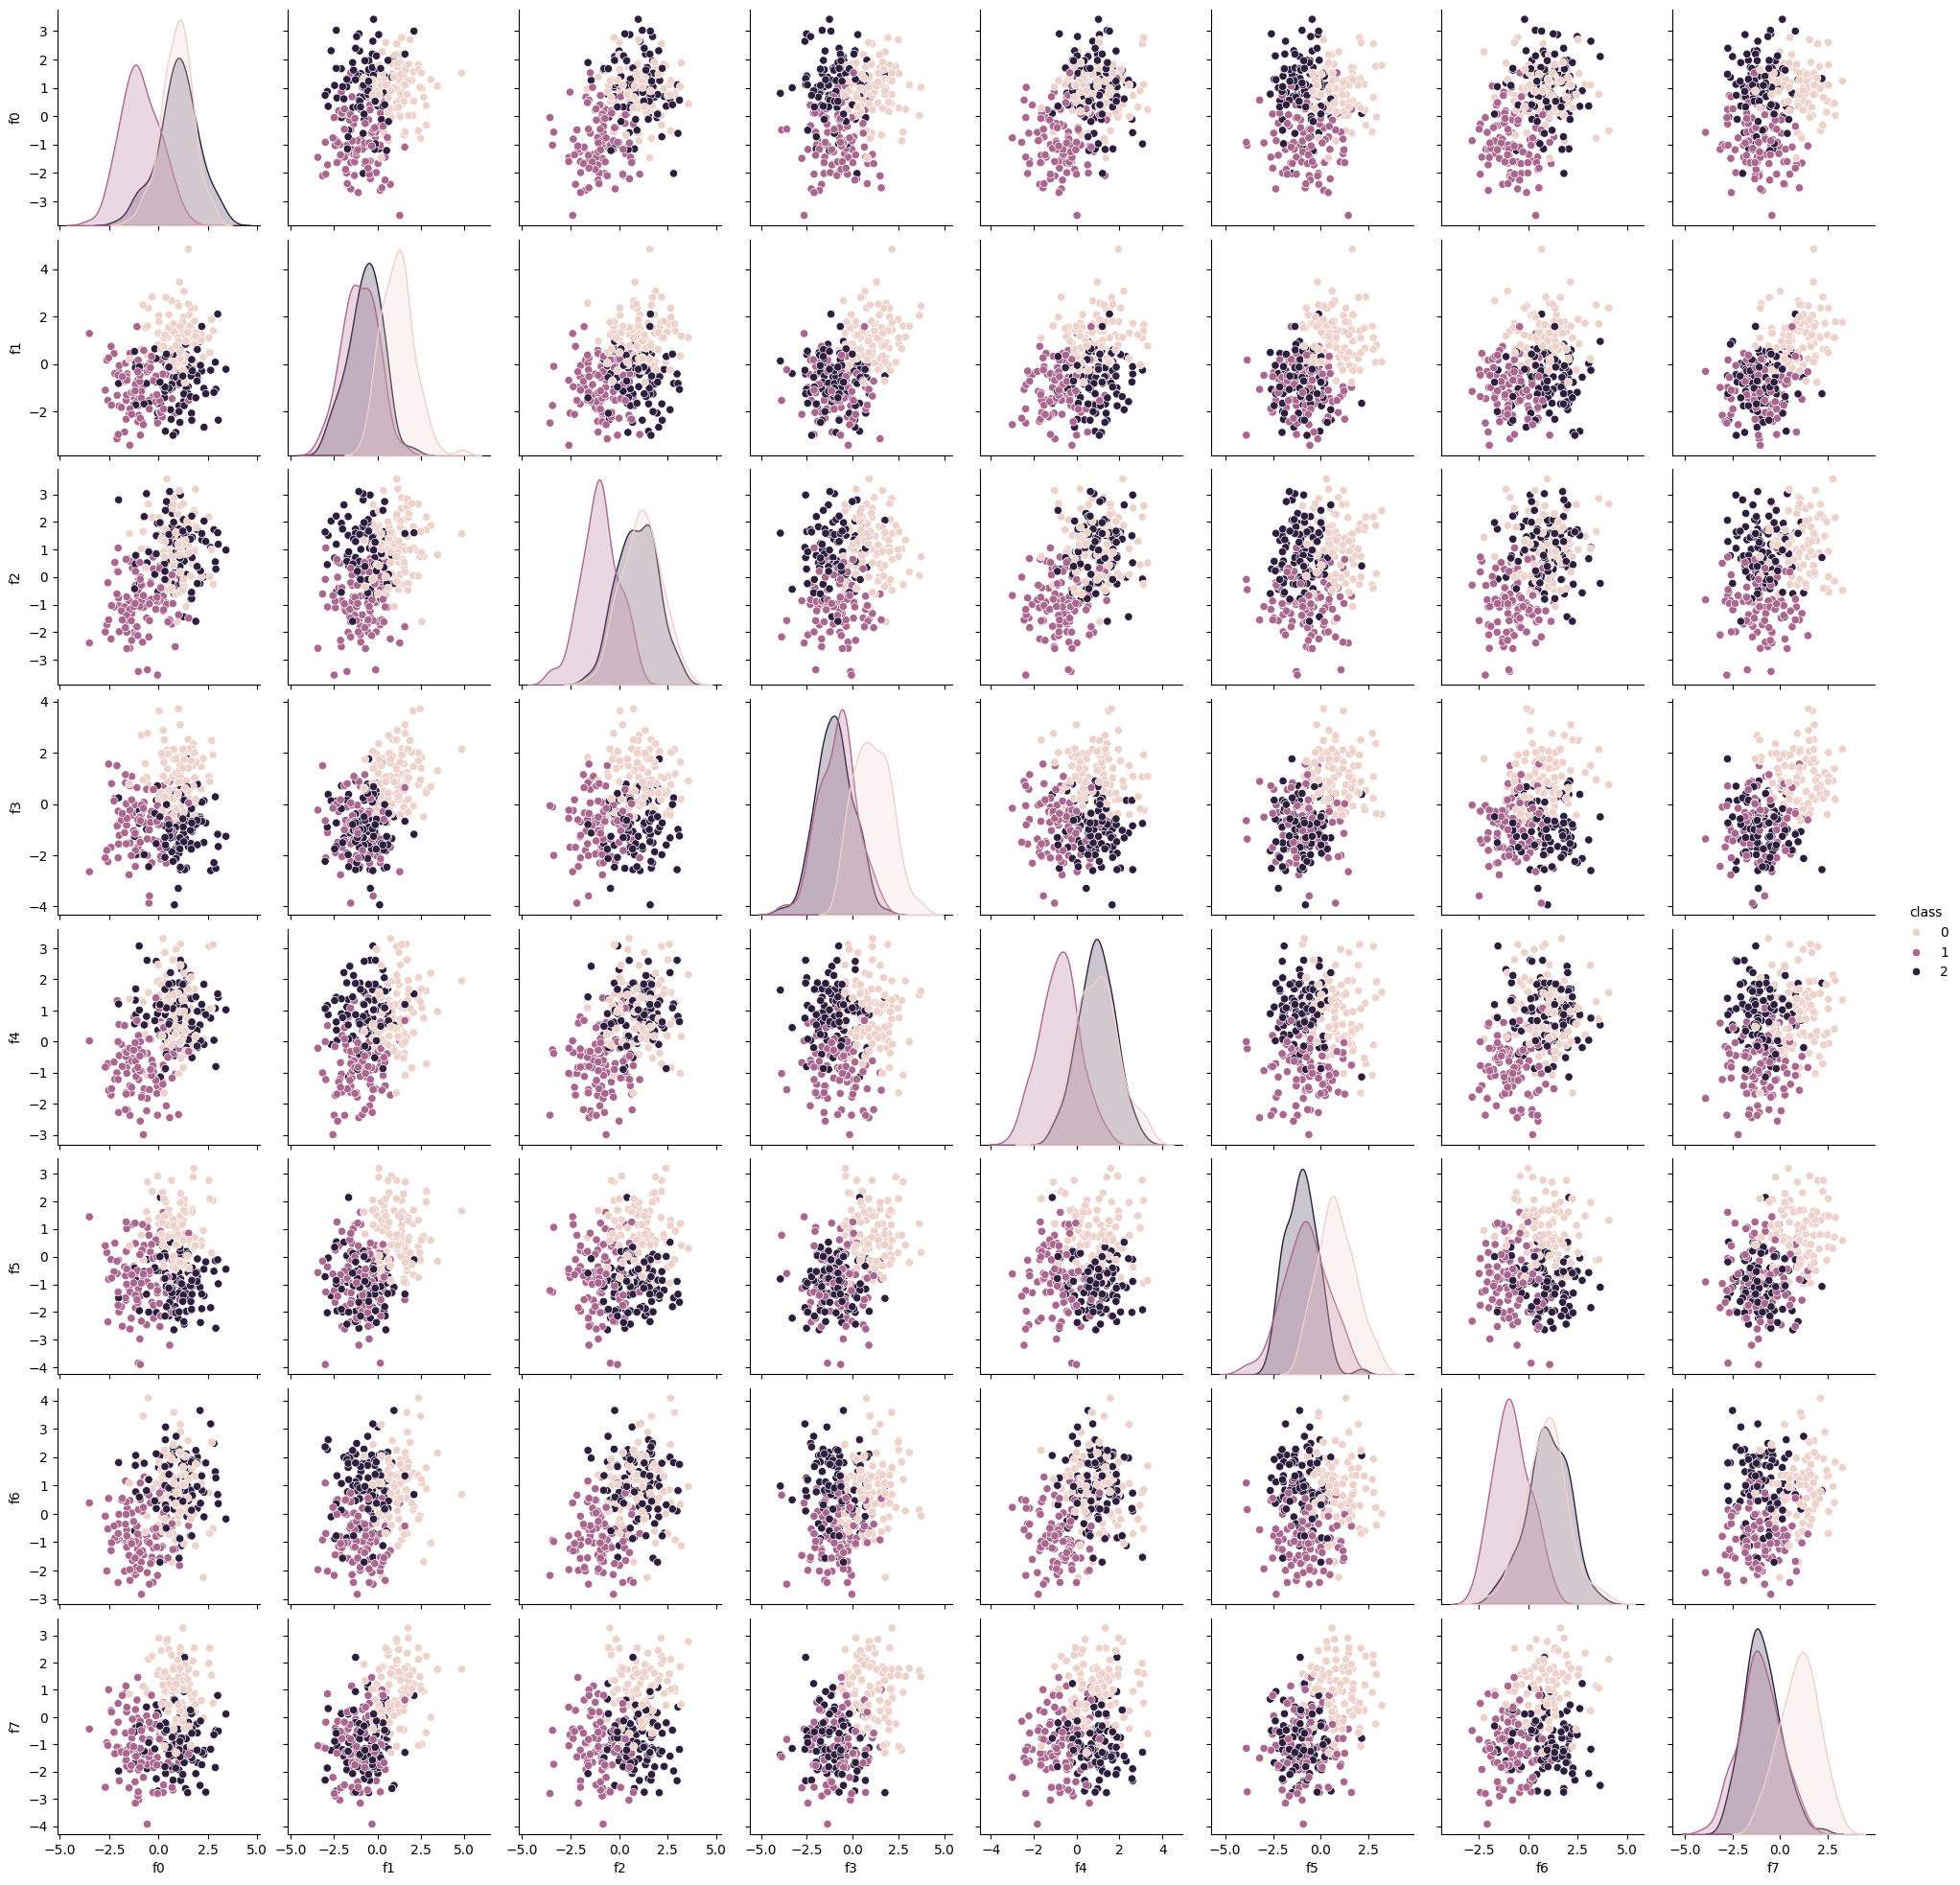

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='class', diag_kind='kde')
plt.show()

## [2]

In [39]:
import pandas as pd
import numpy as np

df0 = df[df['class'] == 0].copy()

results = {}
for A in [1, 10, 100]:
    for B in [1, 10, 100]:
        name = f'df_{A}_{B}'
        new_points = pd.DataFrame(
            np.tile([-B, +B, -B, +B, -B, +B, -B, +B], (A, 1)),
            columns=[f'f{i}' for i in range(8)]
        )
        new_points['class'] = 0
        
        df_ab = pd.concat([
            df0.iloc[:100],  # оригинальные 100 точек класса 0
            new_points,
            df[df['class'] == 1],
            df[df['class'] == 2]
        ], ignore_index=True)
        
        results[name] = df_ab
        print(f"{name}: {len(df_ab)} объектов")

df_1_1: 301 объектов
df_1_10: 301 объектов
df_1_100: 301 объектов
df_10_1: 310 объектов
df_10_10: 310 объектов
df_10_100: 310 объектов
df_100_1: 400 объектов
df_100_10: 400 объектов
df_100_100: 400 объектов


## [3]

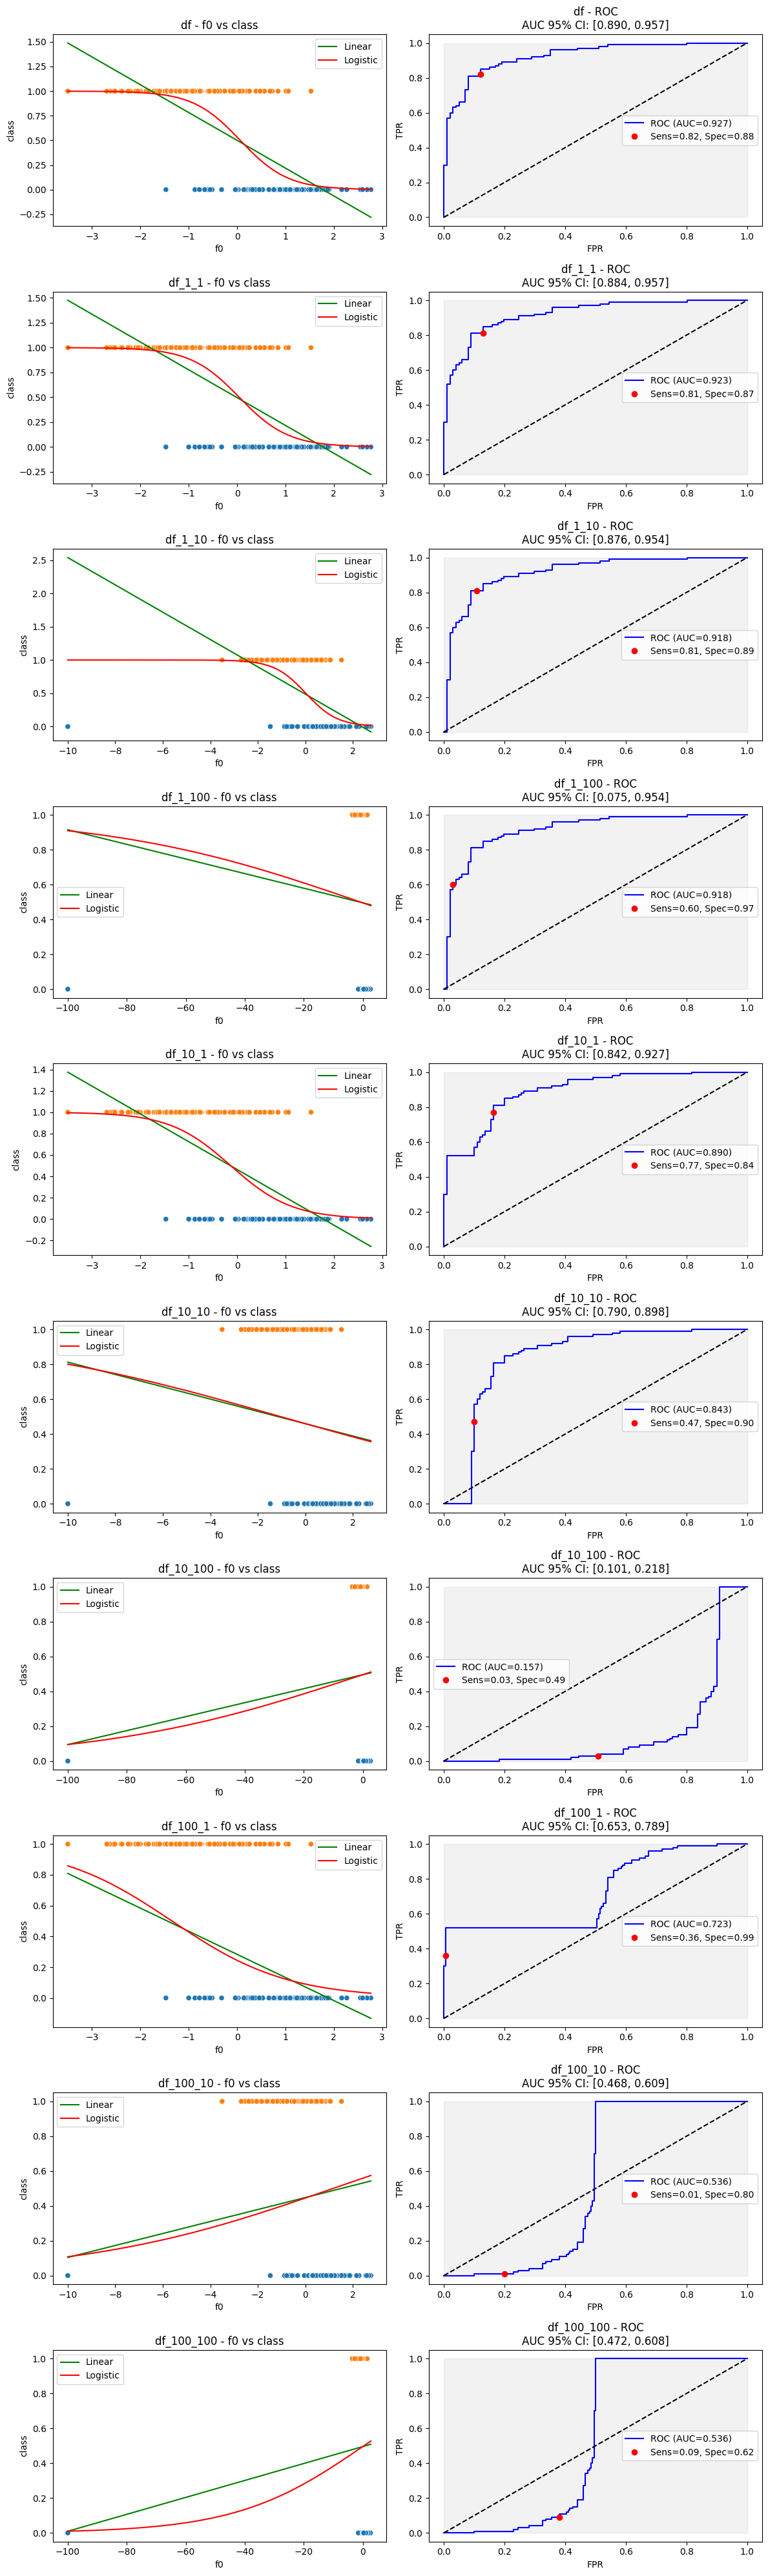

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
import seaborn as sns

datasets = {'df': df} | results  # df + все df_A_B
feature = 'f0'
classes = [0, 1]

fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 4*len(datasets)))
if len(datasets) == 1: axes = axes.reshape(1, -1)

for idx, (name, data) in enumerate(datasets.items()):
    sub = data[data['class'].isin(classes)].copy()
    X = sub[[feature]].values
    y = (sub['class'] == 1).astype(int).values  # 1 vs 0
    
    lin_reg = LinearRegression().fit(X, y)
    log_reg = LogisticRegression().fit(X, y)
    
    x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_lin = lin_reg.predict(x_plot)
    y_log = log_reg.predict_proba(x_plot)[:, 1]
    
    # Левая колонка: пространство + регрессии
    ax1 = axes[idx, 0]
    sns.scatterplot(data=sub, x=feature, y='class', hue='class', ax=ax1, legend=False)
    ax1.plot(x_plot, y_lin, color='green', label='Linear')
    ax1.plot(x_plot, y_log, color='red', label='Logistic')
    ax1.set_title(f"{name} - {feature} vs class")
    ax1.legend()
    
    # ROC и бутстреп CI
    fpr, tpr, thr = roc_curve(y, log_reg.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    
    # Точка классификации (по умолчанию threshold=0.5)
    prob = log_reg.predict_proba(X)[:, 1]
    pred = (prob >= 0.5).astype(int)
    sens = np.mean(pred[y==1] == 1) if (y==1).sum() > 0 else 0
    spec = np.mean(pred[y==0] == 0) if (y==0).sum() > 0 else 0
    
    # Бутстреп CI95 для AUC
    aucs = []
    for _ in range(1000):
        Xb, yb = resample(X, y)
        if len(np.unique(yb)) < 2: continue
        try:
            logb = LogisticRegression().fit(Xb, yb)
            fb, tb, _ = roc_curve(yb, logb.predict_proba(Xb)[:, 1])
            aucs.append(auc(fb, tb))
        except: pass
    ci_low, ci_high = np.percentile(aucs, [2.5, 97.5])
    
    # Правая колонка: ROC
    ax2 = axes[idx, 1]
    ax2.plot(fpr, tpr, color='blue', label=f'ROC (AUC={roc_auc:.3f})')
    ax2.plot([0,1], [0,1], 'k--')
    ax2.plot(1-spec, sens, 'ro', label=f'Sens={sens:.2f}, Spec={spec:.2f}')
    ax2.fill_between([0,1], 0, 1, color='gray', alpha=0.1)
    ax2.set_title(f"{name} - ROC\nAUC 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
    ax2.legend()
    ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')

plt.tight_layout()
plt.show()

## [4]

In [41]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

features = ['f0', 'f1', 'f2', 'f3']
classes = [0, 1]
datasets = {'df': df} | results

log_datasets = {}

for name, data in datasets.items():
    sub = data[data['class'].isin(classes)].copy()
    X = sub[features].values
    y = (sub['class'] == 1).astype(int).values  # 1 для класса 1, 0 для класса 0
    
    # Множественная линейная регрессия
    lin_reg = LinearRegression().fit(X, y)
    coef = lin_reg.coef_
    intercept = lin_reg.intercept_
    
    # Уравнение: Y = intercept + coef[0]*f0 + coef[1]*f1 + coef[2]*f2 + coef[3]*f3
    print(f"{name}: Y = {intercept:.4f} + {coef[0]:.4f}*f0 + {coef[1]:.4f}*f1 + {coef[2]:.4f}*f2 + {coef[3]:.4f}*f3")
    
    # Новый признак X_lin = линейная комбинация
    X_lin = X @ coef + intercept
    logdf = pd.DataFrame({
        'X': X_lin,
        'Y': y
    })
    log_datasets[f'log{name}'] = logdf

logdf.head()

df: Y = 0.5236 + -0.1104*f0 + -0.1042*f1 + -0.1042*f2 + -0.0851*f3
df_1_1: Y = 0.5213 + -0.1074*f0 + -0.1069*f1 + -0.1017*f2 + -0.0874*f3
df_1_10: Y = 0.5240 + -0.0955*f0 + -0.1175*f1 + -0.0923*f2 + -0.0969*f3
df_1_100: Y = 0.5245 + -0.1017*f0 + -0.1120*f1 + -0.0972*f2 + -0.0920*f3
df_10_1: Y = 0.5041 + -0.0859*f0 + -0.1268*f1 + -0.0835*f2 + -0.1039*f3
df_10_10: Y = 0.5241 + -0.0892*f0 + -0.1232*f1 + -0.0872*f2 + -0.1019*f3
df_10_100: Y = 0.5245 + -0.1016*f0 + -0.1120*f1 + -0.0972*f2 + -0.0920*f3
df_100_1: Y = 0.4524 + -0.0212*f0 + -0.1869*f1 + -0.0285*f2 + -0.1537*f3
df_100_10: Y = 0.5241 + -0.0883*f0 + -0.1241*f1 + -0.0864*f2 + -0.1026*f3
df_100_100: Y = 0.5245 + -0.1016*f0 + -0.1120*f1 + -0.0972*f2 + -0.0921*f3


,X,Y
0,-0.020443,0
1,-0.047263,0
2,0.034382,0
3,-0.106675,0
4,-0.038158,0


## [5]

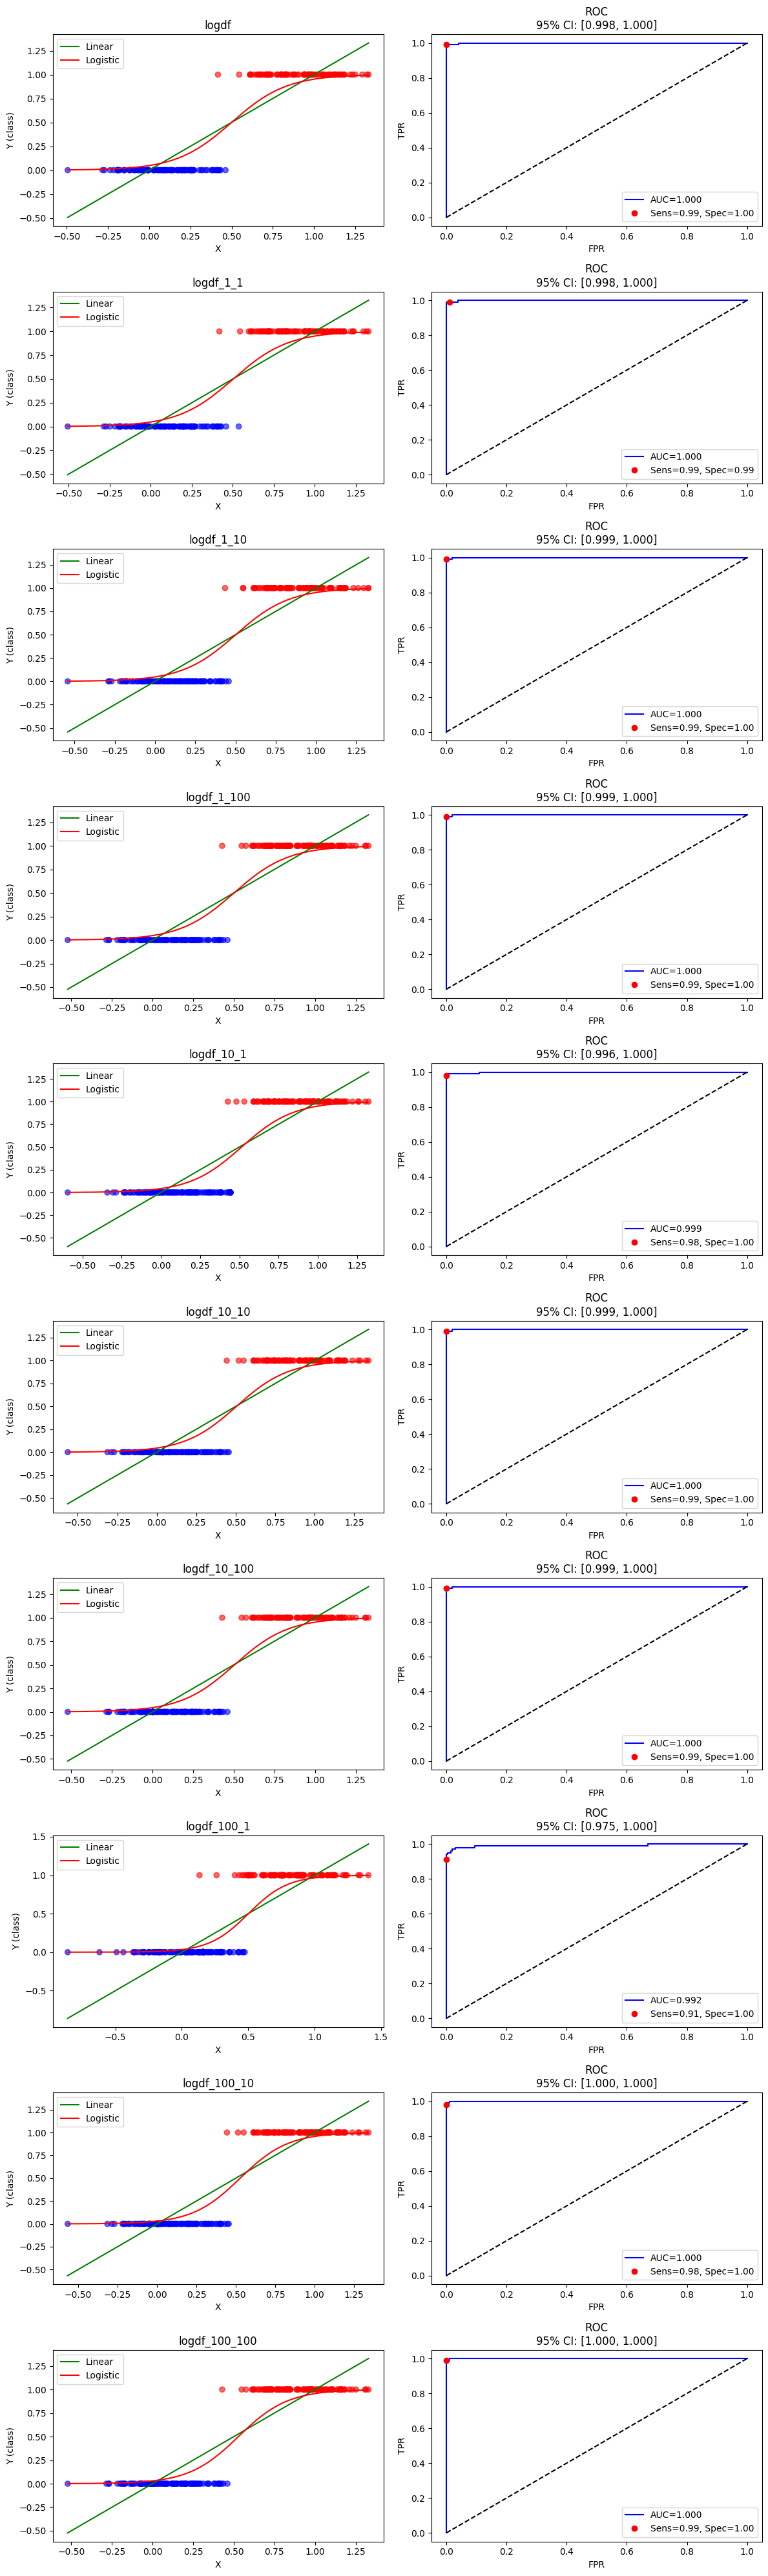

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample

fig, axes = plt.subplots(len(log_datasets), 2, figsize=(12, 4*len(log_datasets)))
if len(log_datasets) == 1: axes = axes.reshape(1, -1)

for idx, (name, data) in enumerate(log_datasets.items()):
    X = data[['X']].values
    y = data['Y'].values
    
    lin_reg = LinearRegression().fit(X, y)
    log_reg = LogisticRegression().fit(X, y)
    
    x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_lin = lin_reg.predict(x_plot)
    y_log = log_reg.predict_proba(x_plot)[:, 1]
    
    # Левая: пространство + регрессии
    ax1 = axes[idx, 0]
    ax1.scatter(X, y, c=y, cmap='bwr', alpha=0.6)
    ax1.plot(x_plot, y_lin, 'g-', label='Linear')
    ax1.plot(x_plot, y_log, 'r-', label='Logistic')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y (class)')
    ax1.set_title(f"{name}")
    ax1.legend()
    
    # ROC + CI
    prob = log_reg.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, prob)
    roc_auc = auc(fpr, tpr)
    
    pred = (prob >= 0.5).astype(int)
    sens = np.mean(pred[y==1] == 1) if (y==1).sum() > 0 else 0
    spec = np.mean(pred[y==0] == 0) if (y==0).sum() > 0 else 0
    
    # Бутстреп CI95 AUC
    aucs = []
    for _ in range(1000):
        Xb, yb = resample(X, y)
        if len(np.unique(yb)) < 2: continue
        try:
            lb = LogisticRegression().fit(Xb, yb)
            fb, tb, _ = roc_curve(yb, lb.predict_proba(Xb)[:, 1])
            aucs.append(auc(fb, tb))
        except: pass
    ci_low, ci_high = np.percentile(aucs, [2.5, 97.5]) if aucs else (0, 0)
    
    # Правая: ROC
    ax2 = axes[idx, 1]
    ax2.plot(fpr, tpr, 'b', label=f'AUC={roc_auc:.3f}')
    ax2.plot([0,1],[0,1],'k--')
    ax2.plot(1-spec, sens, 'ro', label=f'Sens={sens:.2f}, Spec={spec:.2f}')
    ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
    ax2.set_title(f"ROC\n95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
    ax2.legend()

plt.tight_layout()
plt.show()

## [6]

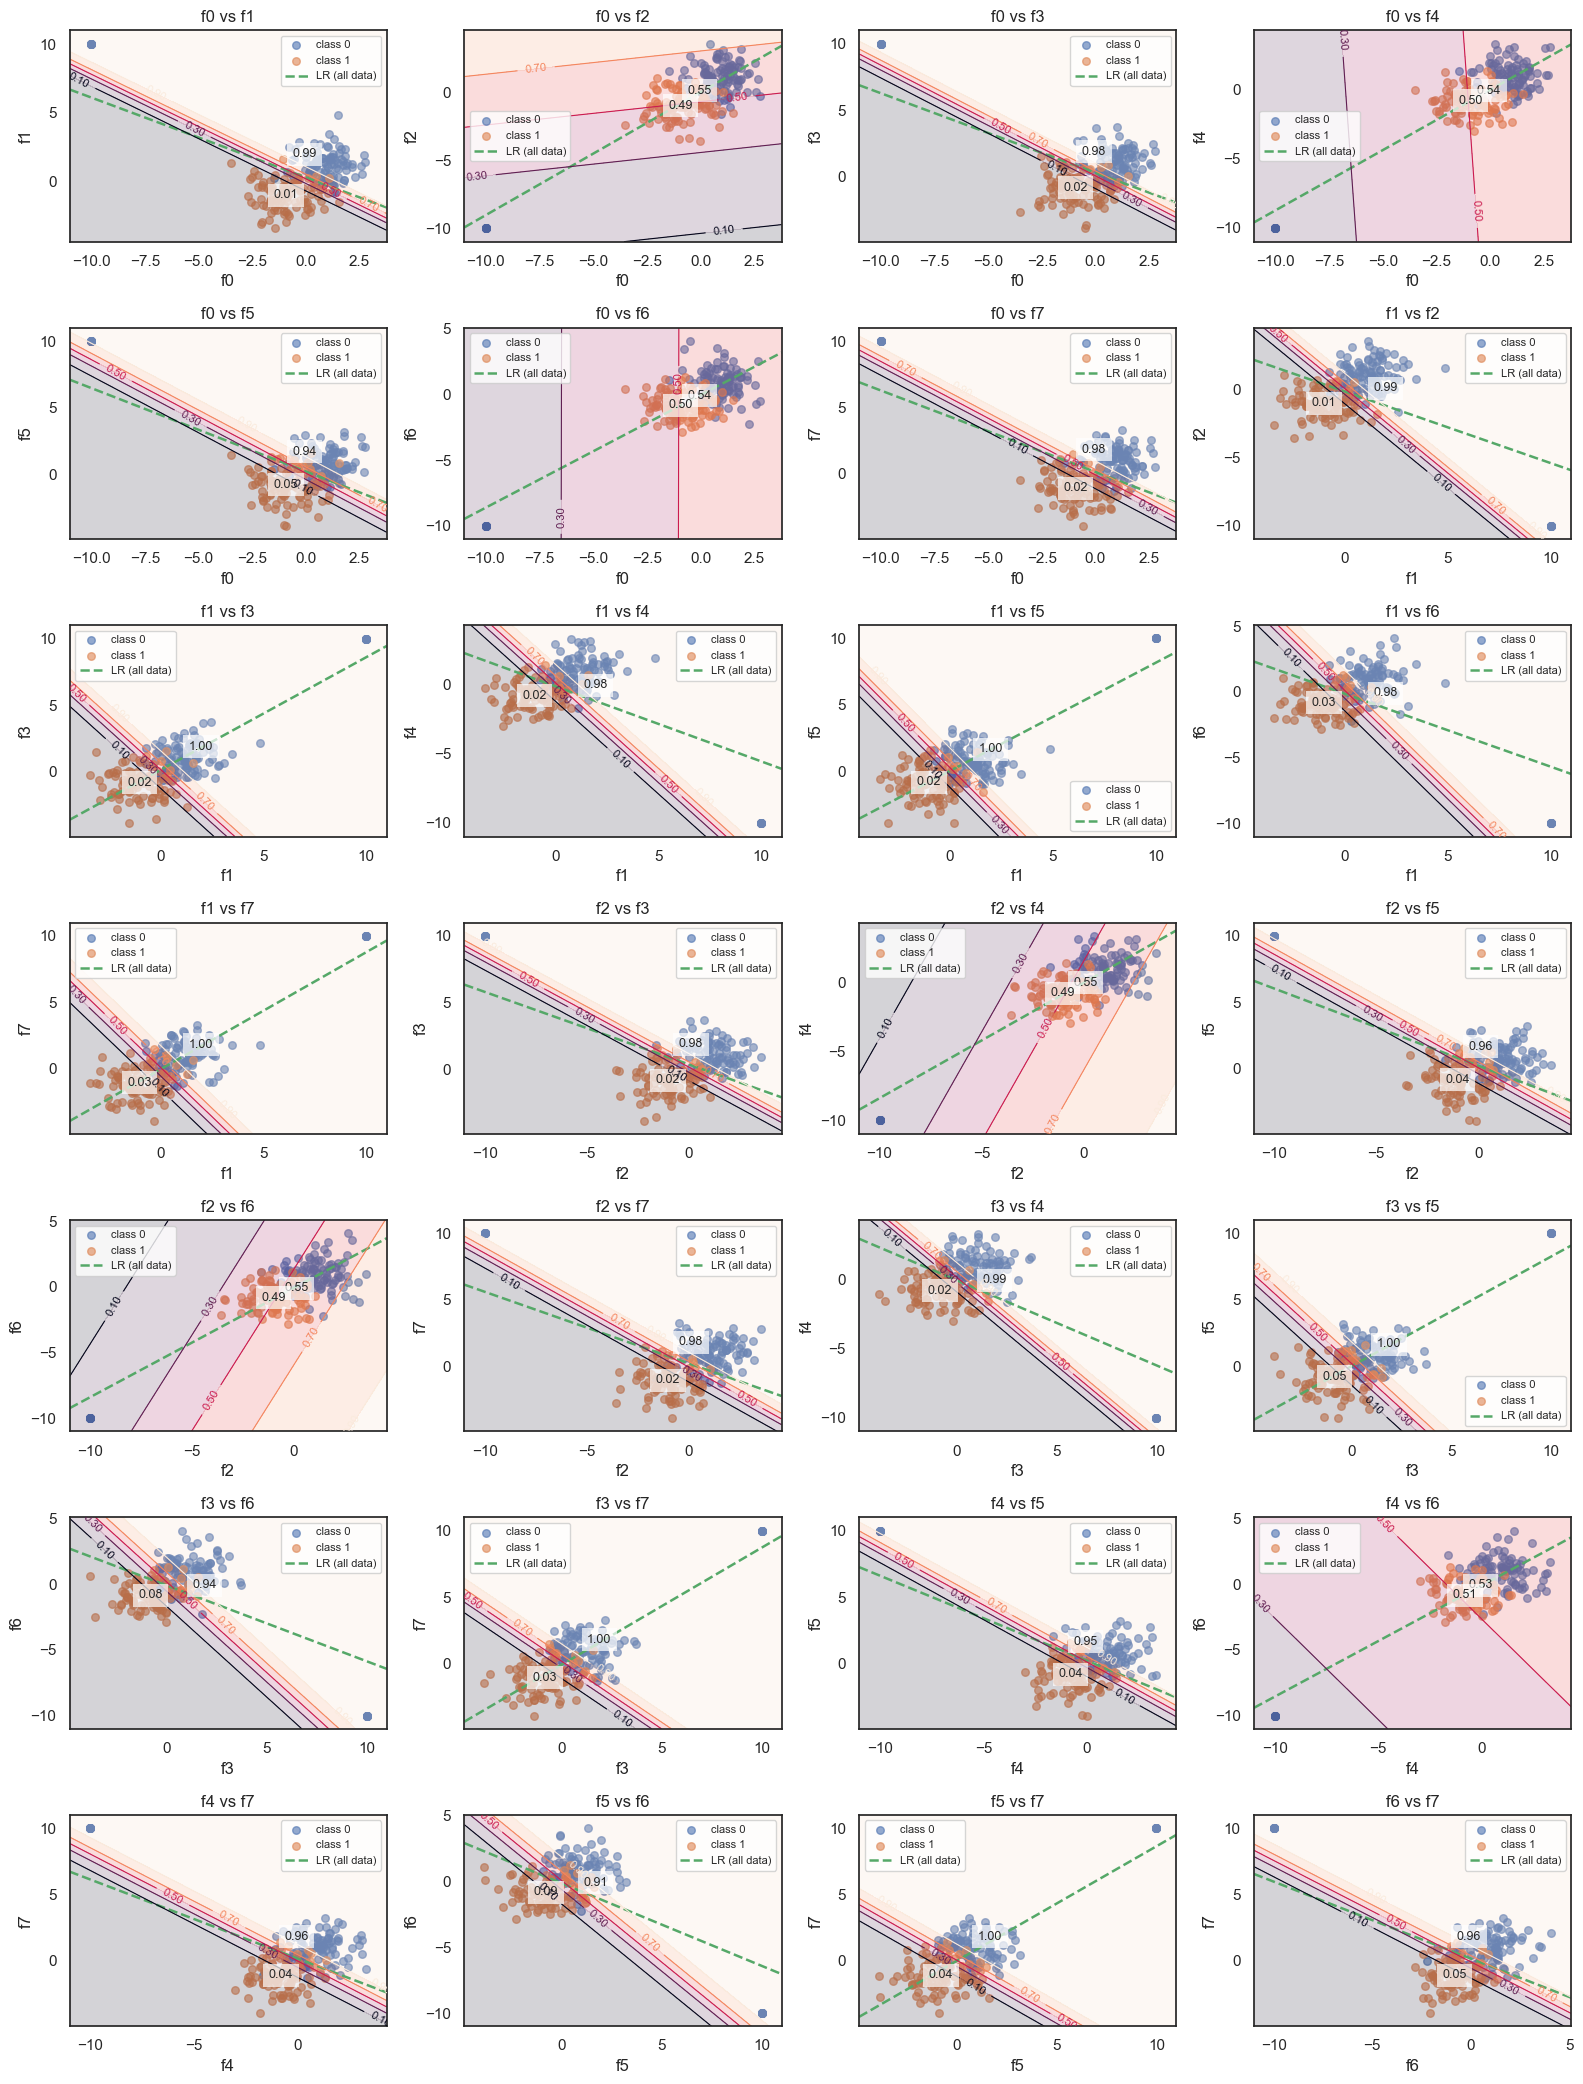

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.linear_model import LogisticRegression, LinearRegression
import warnings
warnings.filterwarnings('ignore')

dataset_name = 'df_10_10'
classes_to_plot = (0, 1)
target_class = classes_to_plot[0]

if 'results' in globals() and dataset_name in results:
    df_ab = results[dataset_name].copy()
else:
    if 'results' in globals() and len(results) > 0:
        df_ab = list(results.values())[0].copy()
        print(f"Warning: '{dataset_name}' не найден. Взял первый dataset из results.")
    else:
        raise RuntimeError("results не найден. Выполните ваш код по генерации results перед запуском этой ячейки.")

# --- фильтрация по двум классам ---
df_pair = df_ab[df_ab['class'].isin(classes_to_plot)].copy()
features = [f'f{i}' for i in range(8)]
pairs = list(combinations(range(8), 2))

# --- подготовка фигуры ---
n_plots = len(pairs)
cols = 4
rows = int(np.ceil(n_plots / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()

# бинарная целевая переменная (1 = target_class)
y_binary = (df_pair['class'] == target_class).astype(int).values

for ax_idx, (i, j) in enumerate(pairs):
    ax = axes[ax_idx]
    xi = df_pair[f'f{i}']
    xj = df_pair[f'f{j}']

    # scatter по классам
    for cls, marker in zip(classes_to_plot, ['o', 's']):
        sel = df_pair['class'] == cls
        ax.scatter(df_pair.loc[sel, f'f{i}'], df_pair.loc[sel, f'f{j}'],
                   label=f'class {cls}', alpha=0.6, s=30)

    # общая линейная регрессия f_j ~ f_i по всем точкам пары классов
    if len(df_pair) >= 2:
        lr_all = LinearRegression().fit(df_pair[[f'f{i}']].values, df_pair[f'f{j}'].values)
        x_line = np.linspace(df_pair[f'f{i}'].min() - 1, df_pair[f'f{i}'].max() + 1, 200).reshape(-1, 1)
        ax.plot(x_line, lr_all.predict(x_line), linestyle='--', color='g', linewidth=1.8, label='LR (all data)')

    # Логистическая регрессия на двух признаках (i,j)
    X_2d = df_pair[[f'f{i}', f'f{j}']].values
    clf = LogisticRegression(solver='liblinear').fit(X_2d, y_binary)

    # Сетка для контуров вероятности
    xm, xM = df_pair[f'f{i}'].min() - 1, df_pair[f'f{i}'].max() + 1
    ym, yM = df_pair[f'f{j}'].min() - 1, df_pair[f'f{j}'].max() + 1
    xxg, yyg = np.meshgrid(np.linspace(xm, xM, 200), np.linspace(ym, yM, 200))
    grid = np.c_[xxg.ravel(), yyg.ravel()]
    probs = clf.predict_proba(grid)[:, 1].reshape(xxg.shape)  # вероятность target_class

    # Контурная заливка и линии; подписи уровней
    levels = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
    ax.contourf(xxg, yyg, probs, levels=levels, alpha=0.18)
    cset = ax.contour(xxg, yyg, probs, levels=[0.1, 0.3, 0.5, 0.7, 0.9], linewidths=0.8)
    ax.clabel(cset, fmt='%.2f', fontsize=8)

    # Подписи вероятности в центроиде каждого класса
    for cls in classes_to_plot:
        centroid = df_pair[df_pair['class'] == cls][[f'f{i}', f'f{j}']].mean().values.reshape(1, -1)
        if centroid.size > 0 and not np.isnan(centroid).any():
            p_cent = clf.predict_proba(centroid)[:, 1][0]
            ax.text(centroid[0, 0], centroid[0, 1], f'{p_cent:.2f}',
                    fontsize=9, ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_xlabel(f'f{i}')
    ax.set_ylabel(f'f{j}')
    ax.set_title(f'f{i} vs f{j}')
    ax.legend(fontsize=8, loc='best')

# убрать пустые оси
for k in range(n_plots, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()
